In [17]:
import numpy as np
import h5py
import time
import inspect

import sys
from pathlib import Path

SRC = Path.cwd().parent
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from matplotlib import pyplot as plt
from helpers.simulation import *
from helpers.qtransform import *
from dataset_generation.gw_class_gen import *
from helpers.config import *

from lisaglitch import LPFLibraryGlitch, ShapeletGlitch, HDF5Glitch, Glitch
from lisainstrument import Instrument

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

In [3]:
def make_tdi_dict(X, Y, Z, whiten=True):
    A, E, T = get_AET(X, Y, Z)

    tdi_dict = {}
    channel_names = ['X', 'Y', 'Z', 'A', 'E', 'T']
    channel_data = [X, Y, Z, A, E, T]
    for i, name in enumerate(channel_names):
        if whiten:
            psd_data = np.load(PSD_PATH / f'psd_{name}.npz')
            f_psd, psd = psd_data['f_psd'], psd_data['psd']
            tdi_dict[name] = whiten_with_psd(channel_data[i], dt=0.25, f_psd=f_psd, psd=psd, alpha=0.1)
        else:
            tdi_dict[name] = channel_data[i]
    return tdi_dict

In [9]:
pipe = {'t0':10368000.0, 'dt':0.25, 'size':int(10*3600/0.25)}

glitches = [{'type':'ShapeletGlitch', 't_inj': 5*3600, 'beta':2e3,
             'level':1e-5, 'inj_point':'tm_12'}]
#glitches = [{'type':'ShapeletGlitch', 't_inj': 0, 'beta':1,
 #            'level':0, 'inj_point':'tm_12'}]

gws = [{'type':'ReducedOneSidedDoubleExpGW', 't_inj': 0, 'amp':0, 't_rise':1, 't_fall':1,
        'gw_beta':0.02*np.pi, 'gw_lambda':0.98*np.pi}]
#gws = [{'type': 'BinaryInspiralGW', 'm1': 1e5, 'm2': 1e5, 'd': 3e3,
 #       'spin1': 0.42, 'spin2': -0.42, 't_inj': 5.9*3600, 'domain': 'freq', 'gw_beta':0.09*np.pi, 'gw_lambda':1.09*np.pi}]

In [16]:
real_glitch_path = str(DIST / 'real_glitch_output.h5')

In [10]:
run_simulation(gws, glitches, pipe,
                gw_path, glitch_path, orbits_path, simulation_path, disable_noise=False)
raw_dict = run_tdi(simulation_path, pipe)

You are using an orbit file in a version that might not be fully supported
Cannot read sampling parameters from '/Users/aryamannrao/Documents/MSc/LISAGlitchSignalClassifier/dist/default_gw_output.h5'
You are using an orbit file in a version that might not be fully supported
Using default set of locking beatnote frequencies might cause interferometric beatnote frequencies to fall outside the requirement range of 5..25 MHz
You are using a measurement file in a version that might not be fully supported (got '2.1.0', official support up to '2.0')


In [11]:
specs = {'low_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(29, 31, 5), 'Q':30,
                      'drange':np.logspace(3, 4, 5)},
         'high_mass': {'trange':(-3, 3), 'frange':(1e-3, 1e-1), 
                      'Qvals':np.linspace(15, 17, 5), 'Q':16,
                      'drange':np.logspace(3, 5, 5)},
         'ext_high_mass': {'trange':(-3, 3), 'frange':(1e-4, 1e-2), 
                       'Qvals':np.linspace(5, 7, 5), 'Q':10,
                       'drange':np.logspace(4, 5, 5)}}

In [22]:
event = glitches[0]
channel = 'X'
res = 256
spec = specs['high_mass']
tdi_dict = make_tdi_dict(raw_dict['X'], raw_dict['Y'], raw_dict['Z'], whiten=False)

start = time.time()
t_arr, f_arr, varQT = varq_transform(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Qvals=spec['Qvals'])
t_arr2, f_arr2, QT = generate_qscan(tdi_dict, channel, pipe, event, resolution=res,
                             frange=spec['frange'], trange=spec['trange'], Q=spec['Q'])
end = time.time()
print(end - start)

4.406718969345093


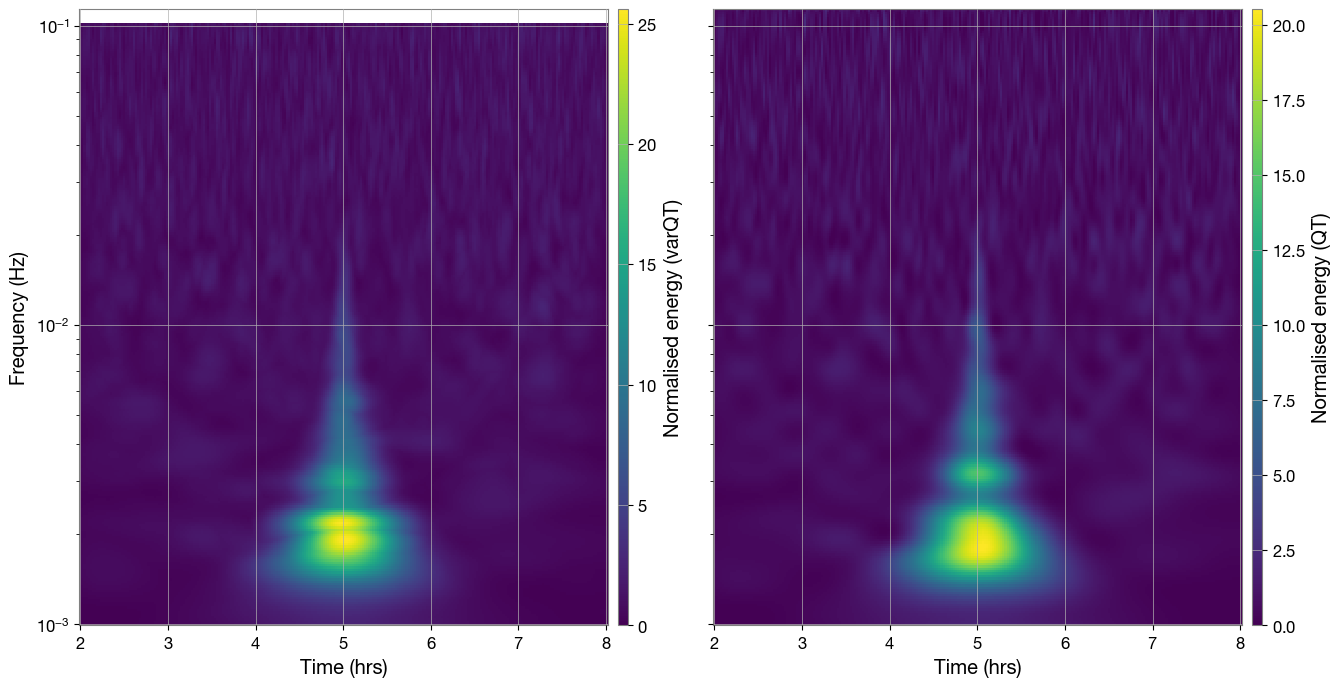

In [23]:
fig, axes = plt.subplots(1, 2, sharey=True, figsize=(15,8))
#title = f'level={event["level"]:.2e}, beta={event["beta"]:.2e}, inj_point={event["inj_point"]}'
#fig.suptitle(title, fontsize=16)

axes[0].pcolormesh(t_arr/3600, f_arr, varQT, cmap='viridis')
axes[1].pcolormesh(t_arr2/3600, f_arr2, QT, cmap='viridis')
axes[0].set_xlabel('Time (hrs)')
axes[1].set_xlabel('Time (hrs)')
axes[0].set_ylabel('Frequency (Hz)')
axes[0].set_yscale('log')
axes[1].set_yscale('log')
axes[0].colorbar(label='Normalised energy (varQT)')
axes[1].colorbar(label='Normalised energy (QT)')
plt.show()

In [15]:
path = str(DIST / 'lpf-glitch-library.h5')
glitch = LPFLibraryGlitch(path=path, inj_point='tm_12', t_inj=5*3600, run=1, glitch=11)

TypeError: only 0-dimensional arrays can be converted to Python scalars

In [19]:
print(help(Glitch))

Help on class Glitch in module lisaglitch.glitch.base:

class Glitch(abc.ABC)
 |  Glitch(inj_point, t_inj=0) -> None
 |  
 |  Abstract base class to represent a single glitch signal.
 |  
 |  A glitch is a time-domain signal which is injected into the instrumental
 |  simulation at a given injection point and at a given time This abstract
 |  class provides a common structure for all glitch classes.
 |  
 |  .. admonition:: Units and time coordinates
 |  
 |      The physical unit and time coordinate associated with a glitch are
 |      defined by the associated injection point.
 |  
 |  Args:
 |      inj_point (str): injection point, see
 |          :const:`lisaglitch.INJECTION_POINTS` for a list of valid injection
 |          points
 |      t_inj (float): injection time [s]
 |  
 |  Method resolution order:
 |      Glitch
 |      abc.ABC
 |      builtins.object
 |  
 |  Methods defined here:
 |  
 |  __init__(self, inj_point, t_inj=0) -> None
 |      Initialize self.  See help(type(s

In [ ]:
glitch.write(str(DIST/ 'real_glitch_output.h5'))

In [7]:
def print_structure(name, obj):
    print(name)

with h5py.File(str(DIST/ 'real_glitch_output.h5'), "r") as f:
    f.visititems(print_structure)

t
tm_12


In [7]:
h5 = h5py.File(path, "r")

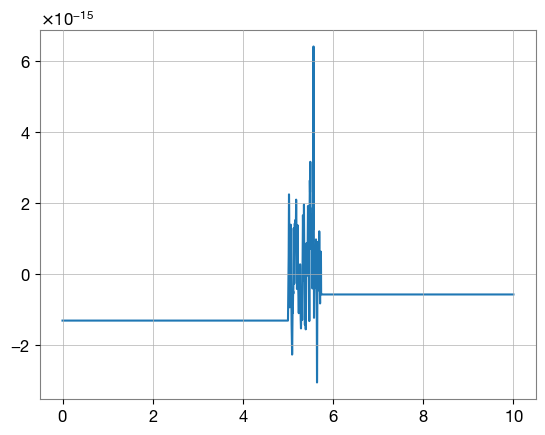

In [9]:
t = np.arange(0, 10*3600, 0.25)
y = glitch.compute_signal(t)

plt.plot(t/3600, y)
plt.show()

In [6]:
h5 = h5py.File(DIST/ 'default_glitch_output.h5', "r")

In [7]:
h5['tm_12']

<HDF5 dataset "tm_12": shape (144000,), type "<f8">

In [89]:
glitch_model = ShapeletGlitch(level=glitches[0]['level'], beta=glitches[0]['beta'], t_inj=5*3600, inj_point=glitches[0]['inj_point'])
t = np.arange(0, 10*3600, 0.25)
y2 = glitch_model.compute_signal(t)

y = np.array(h5['tmi_carrier_fluctuations']['12'])
np.max(y2)/np.max(-y)
#plt.plot(t/3600, y2)
#plt.show()

5.323019495738635e-07

In [4]:
with h5py.File(DIST/ 'default_simulation_output.h5', "r") as f:
    print(list(f.keys()))

['isi_carrier_fluctuations', 'isi_carrier_offsets', 'isi_carriers', 'isi_dws_etas', 'isi_dws_phis', 'isi_usb_fluctuations', 'isi_usb_offsets', 'isi_usbs', 'moc_time_correlations', 'mprs', 'rfi_carrier_fluctuations', 'rfi_carrier_offsets', 'rfi_carriers', 'rfi_usb_fluctuations', 'rfi_usb_offsets', 'rfi_usbs', 'tmi_carrier_fluctuations', 'tmi_carrier_offsets', 'tmi_carriers', 'tmi_usb_fluctuations', 'tmi_usb_offsets', 'tmi_usbs']


In [48]:
h5 = h5py.File(DIST/ 'default_simulation_output.h5', "r")

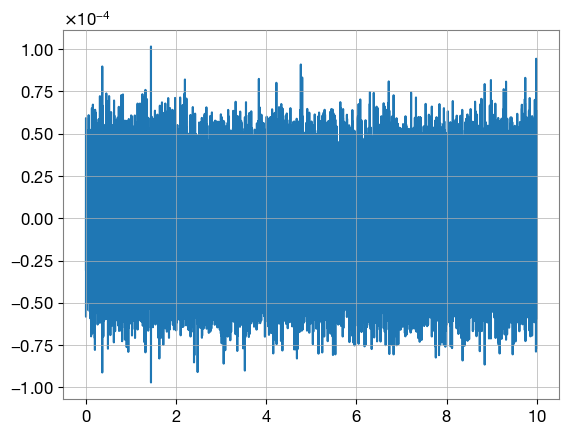

In [55]:
y = np.array(h5['tmi_carrier_fluctuations']['12'])
t = np.arange(0, 10*3600, 0.25)
plt.plot(t/3600, y)

In [45]:
help(Instrument)

Help on class Instrument in module lisainstrument.instrument:

class Instrument(builtins.object)
 |  Instrument(size=2592000, dt=0.25, t0='orbits', physics_upsampling=4, aafilter=('kaiser', 240, 1.1, 2.9), telemetry_downsampling=345600, initial_telemetry_size=0, orbits='static', orbit_dataset='tps/ppr', gws=None, interpolation=('lagrange', 31), glitches=None, lock='N1-12', fplan='static', laser_asds=30, laser_shape='white+infrared', central_freq=281600000000000.0, offset_freqs='default', modulation_asds='default', modulation_freqs='default', tdir_modulations=None, clock_asds=6.32e-14, clock_offsets=0, clock_freqoffsets='default', clock_freqlindrifts='default', clock_freqquaddrifts='default', clockinv_tolerance=1e-10, clockinv_maxiter=5, backlink_asds=3e-12, backlink_fknees=0.002, testmass_asds=2.4e-15, testmass_fknees=0.0004, oms_asds=(6.35e-12, 1.25e-11, 1.42e-12, 3.38e-12, 3.32e-12, 7.9e-12), oms_fknees=0.002, moc_time_correlation_asds=0.42, ttl_coeffs='default', sc_jitter_asds=(5e-0